In [2]:
import torch
import cv2
import segmentation_models_pytorch as smp

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("ALL GOOD 🔥")


Torch version: 2.14.0+cpu
CUDA available: False
ALL GOOD 🔥


In [2]:
import cv2
import matplotlib.pyplot as plt

# change filename if needed
img = cv2.imread("data/sample_retina.jpg")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Retina Image")
plt.show()


error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [3]:
import os

os.listdir("data")


['raw']

In [4]:
import os
os.listdir("data/raw")


['DRIVE']

In [5]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("data/raw/retina_001.jpg")

if img is None:
    raise FileNotFoundError("Image not found. Check path & filename.")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Retina Image")
plt.show()


FileNotFoundError: Image not found. Check path & filename.

In [6]:
import cv2
import matplotlib.pyplot as plt
import os

print(os.listdir("data/raw"))  # sanity check

img_path = "data/raw/PUT_REAL_FILENAME_HERE"

img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Retina Image")
plt.show()


['DRIVE']


FileNotFoundError: Could not load image at data/raw/PUT_REAL_FILENAME_HERE

In [7]:
import os
os.listdir("data/raw")


['DRIVE']

In [8]:
os.listdir("data/raw/DRIVE")


['test', 'training']

In [9]:
os.listdir("data/raw/DRIVE/training")


['1st_manual', 'images', 'mask']

In [10]:
os.listdir("data/raw/DRIVE/training/images")


['21_training.tif',
 '22_training.tif',
 '23_training.tif',
 '24_training.tif',
 '25_training.tif',
 '26_training.tif',
 '27_training.tif',
 '28_training.tif',
 '29_training.tif',
 '30_training.tif',
 '31_training.tif',
 '32_training.tif',
 '33_training.tif',
 '34_training.tif',
 '35_training.tif',
 '36_training.tif',
 '37_training.tif',
 '38_training.tif',
 '39_training.tif',
 '40_training.tif']

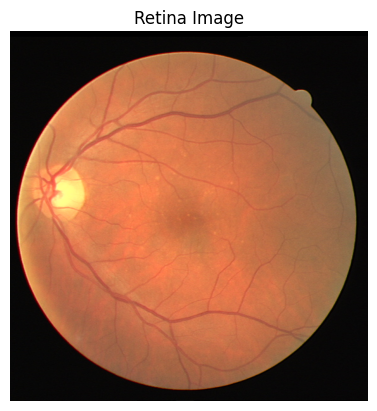

In [11]:
import cv2
import matplotlib.pyplot as plt

img_path = "data/raw/DRIVE/training/images/21_training.tif"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Retina Image")
plt.show()


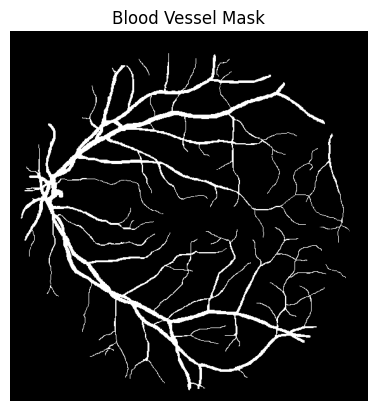

In [12]:
mask_path = "data/raw/DRIVE/training/1st_manual/21_manual1.gif"

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.title("Blood Vessel Mask")
plt.show()


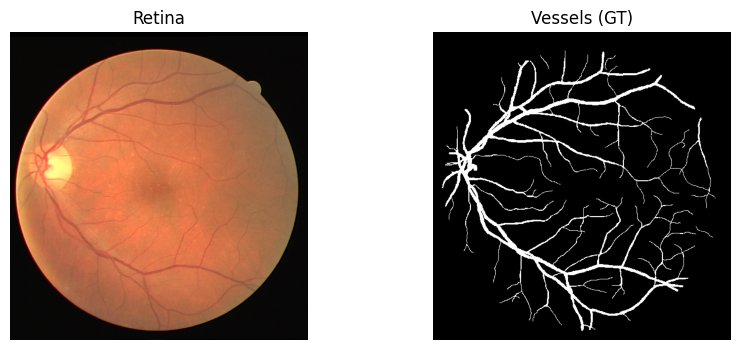

In [13]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Retina")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Vessels (GT)")
plt.axis("off")

plt.show()


In [14]:
import os
import cv2
import torch
from torch.utils.data import Dataset

class RetinaDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.image_dir, self.images[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size))
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # Load mask
        mask_path = os.path.join(self.mask_dir, self.masks[idx])
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        mask = mask / 255.0
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask


In [15]:
train_dataset = RetinaDataset(
    image_dir="data/raw/DRIVE/training/images",
    mask_dir="data/raw/DRIVE/training/1st_manual",
    img_size=256
)

print("Total training samples:", len(train_dataset))


Total training samples: 20


In [16]:
img, mask = train_dataset[0]

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)


Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])


In [1]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

print(model)

NameError: name 'smp' is not defined

In [3]:
import segmentation_models_pytorch as smp
print("SMP version:", smp.__version__)

SMP version: 0.5.0


In [4]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

print(model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05,

In [5]:
loss_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)

print("Loss function:", loss_fn)

Loss function: DiceLoss()


In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

print("Number of batches:", len(train_loader))

NameError: name 'train_dataset' is not defined

In [8]:
train_dataset = RetinaDataset(
    image_dir="data/raw/DRIVE/training/images",
    mask_dir="data/raw/DRIVE/training/1st_manual",
    image_size=(256, 256)
)

print("Total training samples:", len(train_dataset))

NameError: name 'RetinaDataset' is not defined

In [9]:
import os
import cv2
import torch
from torch.utils.data import Dataset

class RetinaDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_size=(256, 256)):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_size = image_size

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, self.image_size)
        mask = cv2.resize(mask, self.image_size)

        image = image / 255.0
        mask = mask / 255.0

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

In [10]:
train_dataset = RetinaDataset(
    image_dir="data/raw/DRIVE/training/images",
    mask_dir="data/raw/DRIVE/training/1st_manual",
    image_size=(256, 256)
)

print("Total training samples:", len(train_dataset))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/raw/DRIVE/training/images'

In [11]:
import os
print(os.getcwd())

c:\Users\Voona\OneDrive\Pictures\Documents\GitHub\retina-blood-vessel-segmentation\notebooks


In [12]:
train_dataset = RetinaDataset(
    image_dir="../data/raw/DRIVE/training/images",
    mask_dir="../data/raw/DRIVE/training/1st_manual",
    image_size=(256, 256)
)

print("Total training samples:", len(train_dataset))

Total training samples: 20


In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

print("Number of batches:", len(train_loader))

Number of batches: 10


In [14]:
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'


In [15]:
for filename in train_dataset.images:
    path = os.path.join(train_dataset.image_dir, filename)
    img = cv2.imread(path)

    if img is None:
        print("PROBLEM IMAGE:", filename)

In [16]:
for filename in train_dataset.masks:
    path = os.path.join(train_dataset.mask_dir, filename)
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        print("PROBLEM MASK:", filename)

PROBLEM MASK: 21_manual1.gif
PROBLEM MASK: 22_manual1.gif
PROBLEM MASK: 23_manual1.gif
PROBLEM MASK: 24_manual1.gif
PROBLEM MASK: 25_manual1.gif
PROBLEM MASK: 26_manual1.gif
PROBLEM MASK: 27_manual1.gif
PROBLEM MASK: 28_manual1.gif
PROBLEM MASK: 29_manual1.gif
PROBLEM MASK: 30_manual1.gif
PROBLEM MASK: 31_manual1.gif
PROBLEM MASK: 32_manual1.gif
PROBLEM MASK: 33_manual1.gif
PROBLEM MASK: 34_manual1.gif
PROBLEM MASK: 35_manual1.gif
PROBLEM MASK: 36_manual1.gif
PROBLEM MASK: 37_manual1.gif
PROBLEM MASK: 38_manual1.gif
PROBLEM MASK: 39_manual1.gif
PROBLEM MASK: 40_manual1.gif


In [17]:
import os
import cv2
import torch
from PIL import Image
from torch.utils.data import Dataset

class RetinaDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_size=(256, 256)):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_size = image_size

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load retina image
        image_path = os.path.join(self.image_dir, self.images[idx])
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load GIF mask using PIL
        mask_path = os.path.join(self.mask_dir, self.masks[idx])
        mask = Image.open(mask_path).convert("L")

        # Convert PIL mask to NumPy
        import numpy as np
        mask = np.array(mask)

        # Resize
        image = cv2.resize(image, self.image_size)
        mask = cv2.resize(mask, self.image_size)

        # Normalize
        image = image / 255.0
        mask = mask / 255.0

        # Convert to PyTorch tensors
        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

In [18]:
train_dataset = RetinaDataset(
    image_dir="../data/raw/DRIVE/training/images",
    mask_dir="../data/raw/DRIVE/training/1st_manual",
    image_size=(256, 256)
)

print("Total training samples:", len(train_dataset))

Total training samples: 20


In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

print("Number of batches:", len(train_loader))

Number of batches: 10


In [20]:
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)

Images: torch.Size([2, 3, 256, 256])
Masks: torch.Size([2, 1, 256, 256])


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Using device:", device)

Using device: cpu


In [22]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        predictions = model(images)

        # Calculate loss
        loss = loss_fn(predictions, masks)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/5] Loss: 0.8140
Epoch [2/5] Loss: 0.7906
Epoch [3/5] Loss: 0.7745
Epoch [4/5] Loss: 0.7608
Epoch [5/5] Loss: 0.7497


In [23]:
model.eval()

with torch.no_grad():
    sample_image = images[0].unsqueeze(0).to(device)
    prediction = model(sample_image)

prediction = torch.sigmoid(prediction)

print("Prediction shape:", prediction.shape)
print("Prediction range:", prediction.min().item(), "to", prediction.max().item())

Prediction shape: torch.Size([1, 1, 256, 256])
Prediction range: 0.09610132873058319 to 0.8872276544570923


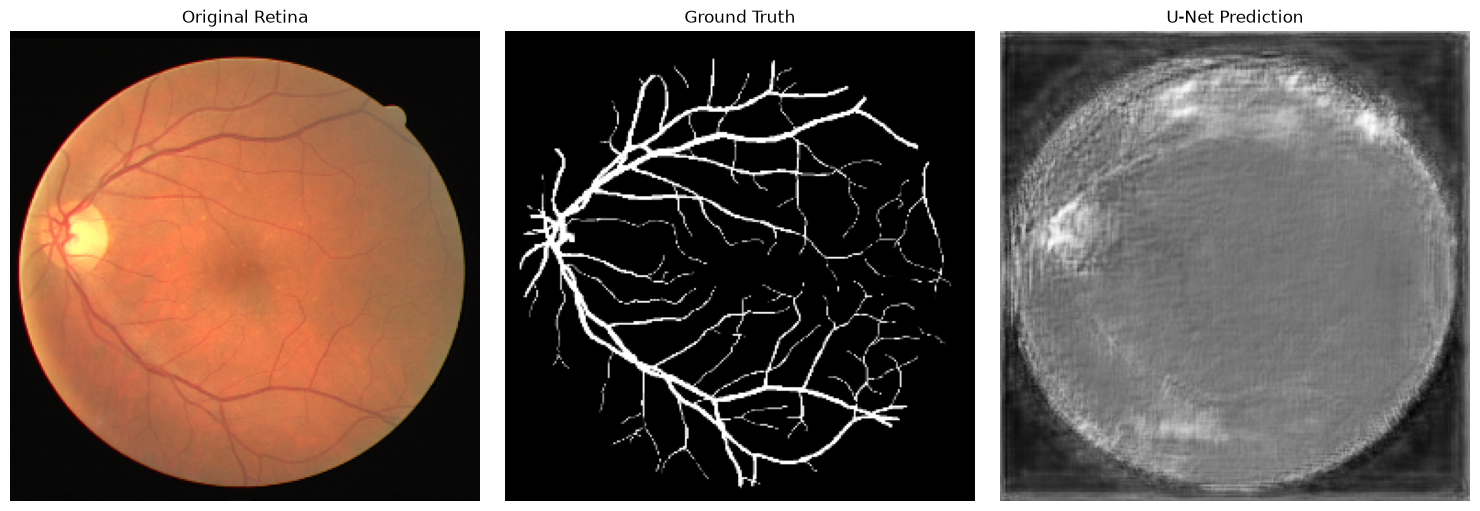

In [24]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    sample_image, sample_mask = train_dataset[0]

    prediction = model(
        sample_image.unsqueeze(0).to(device)
    )

    prediction = torch.sigmoid(prediction)
    prediction = prediction.squeeze().cpu().numpy()

sample_image = sample_image.permute(1, 2, 0).numpy()
sample_mask = sample_mask.squeeze().numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title("Original Retina")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("U-Net Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

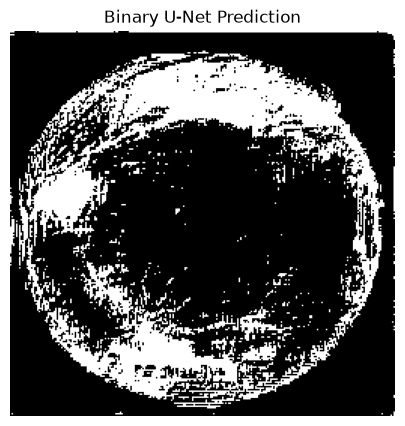

In [25]:
binary_prediction = (prediction > 0.5).astype(float)

plt.figure(figsize=(5, 5))
plt.imshow(binary_prediction, cmap="gray")
plt.title("Binary U-Net Prediction")
plt.axis("off")
plt.show()

In [26]:
print("Mask minimum:", sample_mask.min())
print("Mask maximum:", sample_mask.max())
print("Unique mask values:", sorted(set(sample_mask.flatten()))[:20])

Mask minimum: 0.0
Mask maximum: 1.0
Unique mask values: [0.0, 0.003921569, 0.007843138, 0.011764706, 0.015686275, 0.019607844, 0.023529412, 0.02745098, 0.03137255, 0.03529412, 0.039215688, 0.043137256, 0.047058824, 0.050980393, 0.05490196, 0.05882353, 0.0627451, 0.06666667, 0.07058824, 0.07450981]


In [27]:
import os
import cv2
import torch
from PIL import Image
import numpy as np
from torch.utils.data import Dataset

class RetinaDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_size=(256, 256)):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_size = image_size

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load retina image
        image_path = os.path.join(self.image_dir, self.images[idx])
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load GIF mask using PIL
        mask_path = os.path.join(self.mask_dir, self.masks[idx])
        mask = Image.open(mask_path).convert("L")
        mask = np.array(mask)

        # Resize image normally
        image = cv2.resize(
            image,
            self.image_size,
            interpolation=cv2.INTER_LINEAR
        )

        # Resize mask using nearest-neighbor
        mask = cv2.resize(
            mask,
            self.image_size,
            interpolation=cv2.INTER_NEAREST
        )

        # Normalize
        image = image / 255.0
        mask = mask / 255.0

        # Convert to tensors
        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

In [28]:
train_dataset = RetinaDataset(
    image_dir="../data/raw/DRIVE/training/images",
    mask_dir="../data/raw/DRIVE/training/1st_manual",
    image_size=(256, 256)
)

print("Total training samples:", len(train_dataset))

Total training samples: 20


In [29]:
_, test_mask = train_dataset[0]

print("Mask minimum:", test_mask.min().item())
print("Mask maximum:", test_mask.max().item())
print("Unique mask values:", torch.unique(test_mask))

Mask minimum: 0.0
Mask maximum: 1.0
Unique mask values: tensor([0., 1.])


In [30]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

print("Number of batches:", len(train_loader))

Number of batches: 10


In [31]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

model = model.to(device)

print("Model recreated successfully")

Model recreated successfully


In [32]:
loss_fn = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

print("Loss function:", loss_fn)

Loss function: DiceLoss()


In [33]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [34]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        predictions = model(images)

        loss = loss_fn(predictions, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/5] Loss: 0.8289
Epoch [2/5] Loss: 0.8078
Epoch [3/5] Loss: 0.7916
Epoch [4/5] Loss: 0.7796
Epoch [5/5] Loss: 0.7686


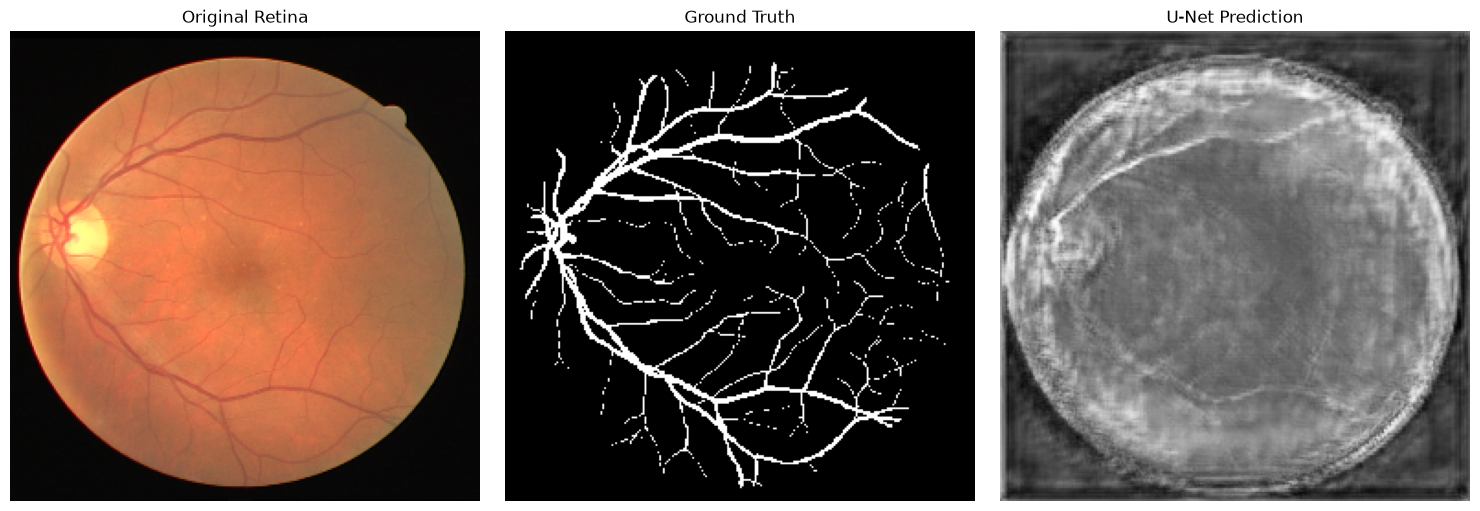

In [35]:
model.eval()

with torch.no_grad():
    sample_image, sample_mask = train_dataset[0]

    prediction = model(
        sample_image.unsqueeze(0).to(device)
    )

    prediction = torch.sigmoid(prediction)
    prediction = prediction.squeeze().cpu().numpy()

sample_image = sample_image.permute(1, 2, 0).numpy()
sample_mask = sample_mask.squeeze().numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title("Original Retina")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("U-Net Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

bce_loss = smp.losses.SoftBCEWithLogitsLoss()

def loss_fn(predictions, masks):
    return dice_loss(predictions, masks) + bce_loss(predictions, masks)

print("Combined Dice + BCE loss ready")

Combined Dice + BCE loss ready


In [37]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        predictions = model(images)

        loss = loss_fn(predictions, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/10] Loss: 1.5762
Epoch [2/10] Loss: 1.4261
Epoch [3/10] Loss: 1.3288
Epoch [4/10] Loss: 1.2624
Epoch [5/10] Loss: 1.2129
Epoch [6/10] Loss: 1.1757
Epoch [7/10] Loss: 1.1334
Epoch [8/10] Loss: 1.1094
Epoch [9/10] Loss: 1.0915
Epoch [10/10] Loss: 1.0627


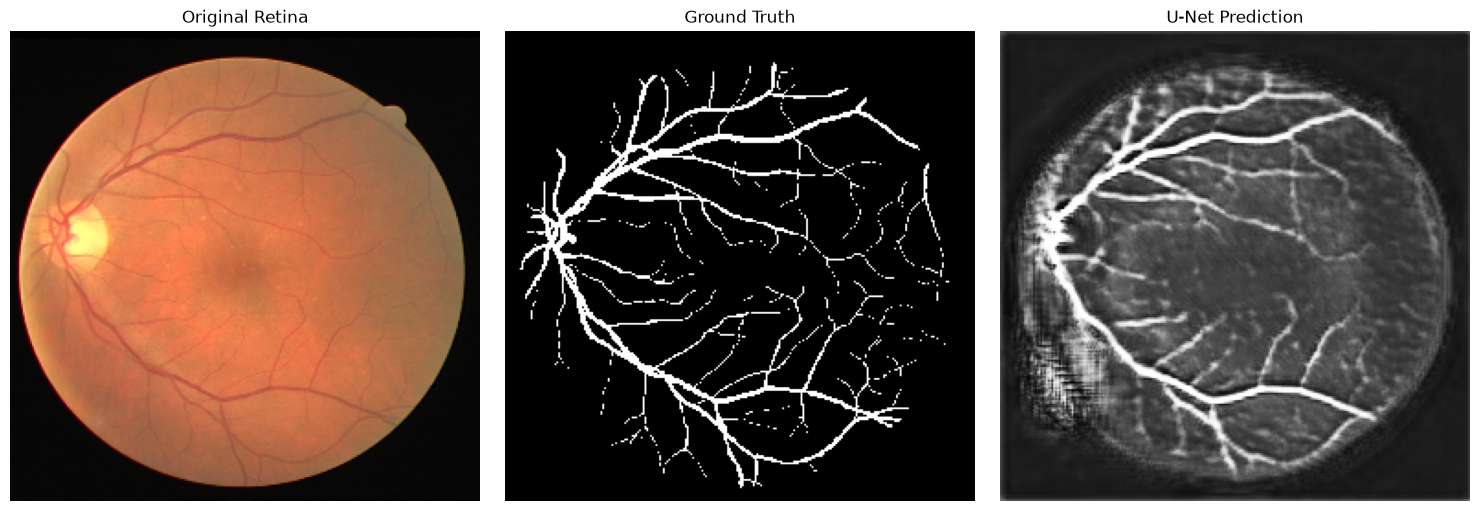

In [38]:
model.eval()

with torch.no_grad():
    sample_image, sample_mask = train_dataset[0]

    prediction = model(
        sample_image.unsqueeze(0).to(device)
    )

    prediction = torch.sigmoid(prediction)
    prediction = prediction.squeeze().cpu().numpy()

sample_image = sample_image.permute(1, 2, 0).numpy()
sample_mask = sample_mask.squeeze().numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title("Original Retina")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("U-Net Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        predictions = model(images)

        loss = loss_fn(predictions, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 16}/25] "
        f"Loss: {average_loss:.4f}"
    )

Epoch [16/25] Loss: 1.0399
Epoch [17/25] Loss: 1.0152
Epoch [18/25] Loss: 0.9976
Epoch [19/25] Loss: 0.9792
Epoch [20/25] Loss: 0.9613
Epoch [21/25] Loss: 0.9467
Epoch [22/25] Loss: 0.9304
Epoch [23/25] Loss: 0.9096
Epoch [24/25] Loss: 0.8949
Epoch [25/25] Loss: 0.8765


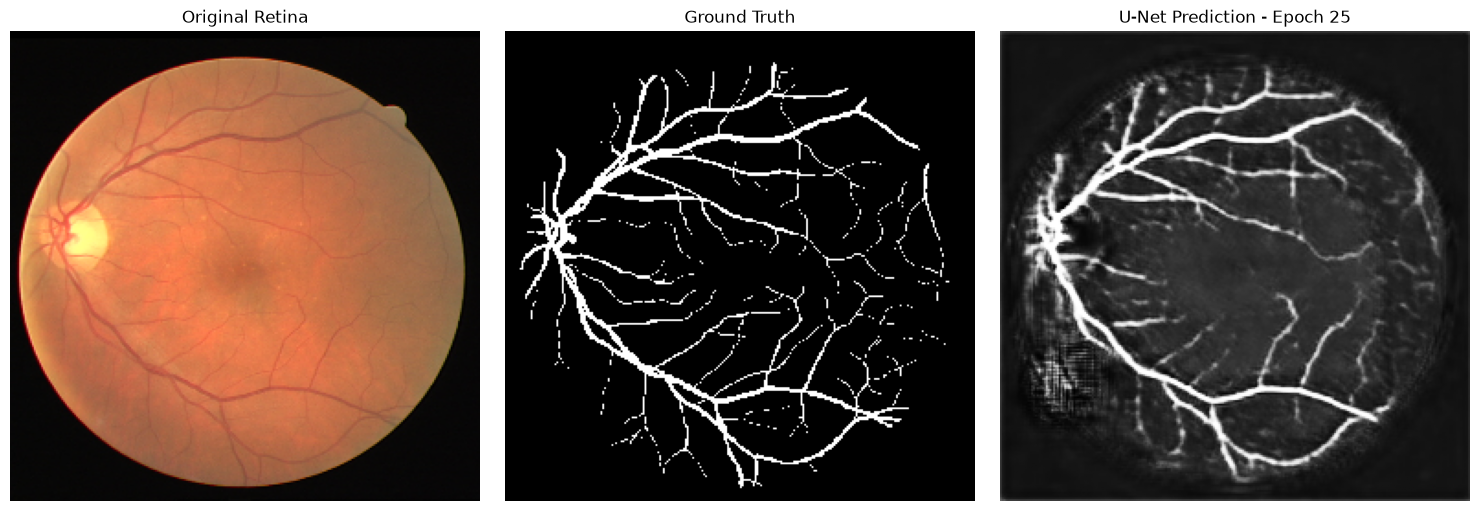

In [40]:
model.eval()

with torch.no_grad():
    sample_image, sample_mask = train_dataset[0]

    prediction = model(
        sample_image.unsqueeze(0).to(device)
    )

    prediction = torch.sigmoid(prediction)
    prediction = prediction.squeeze().cpu().numpy()

sample_image = sample_image.permute(1, 2, 0).numpy()
sample_mask = sample_mask.squeeze().numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title("Original Retina")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("U-Net Prediction - Epoch 25")
plt.axis("off")

plt.tight_layout()
plt.show()

In [41]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        predictions = model(images)

        loss = loss_fn(predictions, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 26}/35] "
        f"Loss: {average_loss:.4f}"
    )

Epoch [26/35] Loss: 0.8628
Epoch [27/35] Loss: 0.8471
Epoch [28/35] Loss: 0.8318
Epoch [29/35] Loss: 0.8170
Epoch [30/35] Loss: 0.7992
Epoch [31/35] Loss: 0.7865
Epoch [32/35] Loss: 0.7701
Epoch [33/35] Loss: 0.7517
Epoch [34/35] Loss: 0.7343
Epoch [35/35] Loss: 0.7229


In [42]:
model.eval()

total_dice = 0.0
total_iou = 0.0
num_samples = 0

with torch.no_grad():
    for image, mask in train_dataset:
        image = image.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0).to(device)

        output = model(image)
        prediction = torch.sigmoid(output)

        # Convert probability map to binary mask
        prediction = (prediction > 0.5).float()

        # Flatten
        prediction_flat = prediction.view(-1)
        mask_flat = mask.view(-1)

        # Dice Score
        intersection = (prediction_flat * mask_flat).sum()

        dice = (
            (2 * intersection + 1e-7)
            / (prediction_flat.sum() + mask_flat.sum() + 1e-7)
        )

        # IoU
        union = (
            prediction_flat.sum()
            + mask_flat.sum()
            - intersection
        )

        iou = (intersection + 1e-7) / (union + 1e-7)

        total_dice += dice.item()
        total_iou += iou.item()
        num_samples += 1

average_dice = total_dice / num_samples
average_iou = total_iou / num_samples

print(f"Training Dice Score: {average_dice:.4f}")
print(f"Training IoU Score:  {average_iou:.4f}")

Training Dice Score: 0.7079
Training IoU Score:  0.5484


In [43]:
import os

print("Test images:")
print(os.listdir("../data/raw/DRIVE/test/images")[:5])

print("\nTest masks:")
print(os.listdir("../data/raw/DRIVE/test/1st_manual")[:5])

Test images:
['01_test.tif', '02_test.tif', '03_test.tif', '04_test.tif', '05_test.tif']

Test masks:
['01_manual1.gif', '02_manual1.gif', '03_manual1.gif', '04_manual1.gif', '05_manual1.gif']


In [44]:
test_dataset = RetinaDataset(
    image_dir="../data/raw/DRIVE/test/images",
    mask_dir="../data/raw/DRIVE/test/1st_manual",
    image_size=(256, 256)
)

print("Total test samples:", len(test_dataset))

Total test samples: 20


In [45]:
model.eval()

test_dice = 0.0
test_iou = 0.0
num_samples = 0

with torch.no_grad():
    for image, mask in test_dataset:
        image = image.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0).to(device)

        output = model(image)
        prediction = torch.sigmoid(output)

        # Convert probabilities to binary vessel mask
        prediction = (prediction > 0.5).float()

        # Flatten
        prediction_flat = prediction.view(-1)
        mask_flat = mask.view(-1)

        # Dice
        intersection = (prediction_flat * mask_flat).sum()

        dice = (
            (2 * intersection + 1e-7)
            / (prediction_flat.sum() + mask_flat.sum() + 1e-7)
        )

        # IoU
        union = (
            prediction_flat.sum()
            + mask_flat.sum()
            - intersection
        )

        iou = (intersection + 1e-7) / (union + 1e-7)

        test_dice += dice.item()
        test_iou += iou.item()
        num_samples += 1

average_test_dice = test_dice / num_samples
average_test_iou = test_iou / num_samples

print(f"Test Dice Score: {average_test_dice:.4f}")
print(f"Test IoU Score:  {average_test_iou:.4f}")

Test Dice Score: 0.6511
Test IoU Score:  0.4836


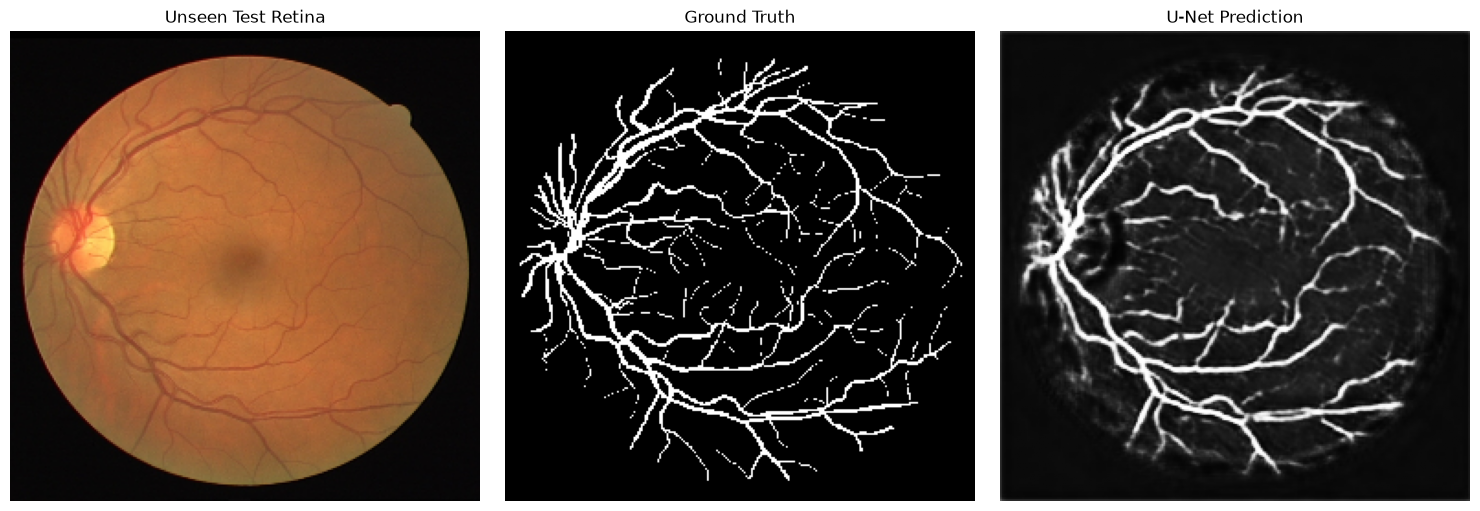

In [46]:
model.eval()

with torch.no_grad():
    test_image, test_mask = test_dataset[0]

    output = model(
        test_image.unsqueeze(0).to(device)
    )

    test_prediction = torch.sigmoid(output)
    test_prediction = test_prediction.squeeze().cpu().numpy()

test_image_np = test_image.permute(1, 2, 0).numpy()
test_mask_np = test_mask.squeeze().numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(test_image_np)
plt.title("Unseen Test Retina")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(test_mask_np, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(test_prediction, cmap="gray")
plt.title("U-Net Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

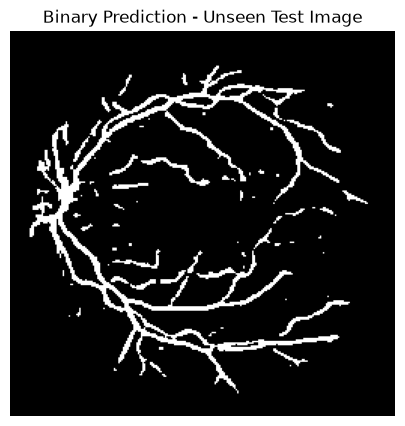

In [47]:
binary_test_prediction = (test_prediction > 0.5).astype(float)

plt.figure(figsize=(5, 5))

plt.imshow(binary_test_prediction, cmap="gray")
plt.title("Binary Prediction - Unseen Test Image")
plt.axis("off")

plt.show()

In [48]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    total_dice = 0.0
    total_iou = 0.0

    with torch.no_grad():
        for image, mask in test_dataset:
            image = image.unsqueeze(0).to(device)
            mask = mask.unsqueeze(0).to(device)

            output = model(image)
            prediction = torch.sigmoid(output)

            prediction = (prediction > threshold).float()

            pred_flat = prediction.view(-1)
            mask_flat = mask.view(-1)

            intersection = (pred_flat * mask_flat).sum()

            dice = (
                (2 * intersection + 1e-7)
                / (pred_flat.sum() + mask_flat.sum() + 1e-7)
            )

            union = (
                pred_flat.sum()
                + mask_flat.sum()
                - intersection
            )

            iou = (intersection + 1e-7) / (union + 1e-7)

            total_dice += dice.item()
            total_iou += iou.item()

    avg_dice = total_dice / len(test_dataset)
    avg_iou = total_iou / len(test_dataset)

    print(
        f"Threshold {threshold:.1f} | "
        f"Dice: {avg_dice:.4f} | "
        f"IoU: {avg_iou:.4f}"
    )

Threshold 0.3 | Dice: 0.6205 | IoU: 0.4504
Threshold 0.4 | Dice: 0.6459 | IoU: 0.4777
Threshold 0.5 | Dice: 0.6511 | IoU: 0.4836
Threshold 0.6 | Dice: 0.6421 | IoU: 0.4741
Threshold 0.7 | Dice: 0.6208 | IoU: 0.4519


In [49]:
import os

os.makedirs("../models", exist_ok=True)

torch.save(
    model.state_dict(),
    "../models/unet_resnet34_baseline.pth"
)

print("Baseline model saved successfully!")

Baseline model saved successfully!


In [50]:
from torch.utils.data import random_split

# Split the 20 training images into:
# 16 images for training
# 4 images for validation

train_size = 16
val_size = 4

train_dataset_split, val_dataset_split = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training images:", len(train_dataset_split))
print("Validation images:", len(val_dataset_split))

Training images: 16
Validation images: 4


In [51]:
train_loader = DataLoader(
    train_dataset_split,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset_split,
    batch_size=2,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 8
Validation batches: 2


In [52]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

model = model.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Fresh U-Net model created.")

Fresh U-Net model created.


In [53]:
model.train()

for images, masks in train_loader:
    images = images.to(device)
    masks = masks.to(device)

    optimizer.zero_grad()

    predictions = model(images)

    loss = loss_fn(predictions, masks)

    loss.backward()
    optimizer.step()

print("1 training epoch completed.")

1 training epoch completed.


In [54]:
model.eval()

val_dice = 0.0
val_iou = 0.0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        predictions = model(images)
        predictions = torch.sigmoid(predictions)

        predictions = (predictions > 0.5).float()

        intersection = (predictions * masks).sum()
        dice = (2 * intersection) / (
            predictions.sum() + masks.sum() + 1e-7
        )

        union = (
            predictions.sum()
            + masks.sum()
            - intersection
        )

        iou = intersection / (union + 1e-7)

        val_dice += dice.item()
        val_iou += iou.item()

val_dice /= len(val_loader)
val_iou /= len(val_loader)

print(f"Validation Dice: {val_dice:.4f}")
print(f"Validation IoU: {val_iou:.4f}")

Validation Dice: 0.0511
Validation IoU: 0.0262


In [55]:
for epoch in range(9):
    model.train()
    total_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        predictions = model(images)

        loss = loss_fn(predictions, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 2}/10 - Loss: {avg_loss:.4f}")

Epoch 2/10 - Loss: 1.5578
Epoch 3/10 - Loss: 1.4942
Epoch 4/10 - Loss: 1.4449
Epoch 5/10 - Loss: 1.4045
Epoch 6/10 - Loss: 1.3666
Epoch 7/10 - Loss: 1.3323
Epoch 8/10 - Loss: 1.3022
Epoch 9/10 - Loss: 1.2744
Epoch 10/10 - Loss: 1.2485


In [56]:
model.eval()

val_dice = 0.0
val_iou = 0.0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        predictions = model(images)
        predictions = torch.sigmoid(predictions)

        predictions = (predictions > 0.5).float()

        intersection = (predictions * masks).sum()
        dice = (2 * intersection) / (
            predictions.sum() + masks.sum() + 1e-7
        )

        union = (
            predictions.sum()
            + masks.sum()
            - intersection
        )

        iou = intersection / (union + 1e-7)

        val_dice += dice.item()
        val_iou += iou.item()

val_dice /= len(val_loader)
val_iou /= len(val_loader)

print(f"Validation Dice: {val_dice:.4f}")
print(f"Validation IoU: {val_iou:.4f}")

Validation Dice: 0.2009
Validation IoU: 0.1163


In [57]:
for epoch in range(25):
    model.train()
    total_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        predictions = model(images)

        loss = loss_fn(predictions, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 11}/35 - Loss: {avg_loss:.4f}")

Epoch 11/35 - Loss: 1.2244
Epoch 12/35 - Loss: 1.2023
Epoch 13/35 - Loss: 1.1791
Epoch 14/35 - Loss: 1.1571
Epoch 15/35 - Loss: 1.1344
Epoch 16/35 - Loss: 1.1151
Epoch 17/35 - Loss: 1.0945
Epoch 18/35 - Loss: 1.0721
Epoch 19/35 - Loss: 1.0537
Epoch 20/35 - Loss: 1.0349
Epoch 21/35 - Loss: 1.0166
Epoch 22/35 - Loss: 1.0030
Epoch 23/35 - Loss: 0.9857
Epoch 24/35 - Loss: 0.9730
Epoch 25/35 - Loss: 0.9522
Epoch 26/35 - Loss: 0.9373
Epoch 27/35 - Loss: 0.9205
Epoch 28/35 - Loss: 0.9029
Epoch 29/35 - Loss: 0.8894
Epoch 30/35 - Loss: 0.8752
Epoch 31/35 - Loss: 0.8573
Epoch 32/35 - Loss: 0.8443
Epoch 33/35 - Loss: 0.8290
Epoch 34/35 - Loss: 0.8136
Epoch 35/35 - Loss: 0.7982


In [58]:
model.eval()

val_dice = 0.0
val_iou = 0.0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        predictions = model(images)
        predictions = torch.sigmoid(predictions)

        predictions = (predictions > 0.5).float()

        intersection = (predictions * masks).sum()
        dice = (2 * intersection) / (
            predictions.sum() + masks.sum() + 1e-7
        )

        union = predictions.sum() + masks.sum() - intersection
        iou = intersection / (union + 1e-7)

        val_dice += dice.item()
        val_iou += iou.item()

val_dice /= len(val_loader)
val_iou /= len(val_loader)

print(f"Validation Dice: {val_dice:.4f}")
print(f"Validation IoU: {val_iou:.4f}")

Validation Dice: 0.4845
Validation IoU: 0.3200


In [59]:
torch.save(
    model.state_dict(),
    "../models/unet_resnet34_validation35.pth"
)

print("Validation model saved successfully!")

Validation model saved successfully!


In [60]:
import random

print("Augmentation setup ready.")

Augmentation setup ready.


In [61]:
import torchvision.transforms.functional as TF

class AugmentedRetinaDataset(RetinaDataset):

    def __getitem__(self, idx):
        image, mask = super().__getitem__(idx)

        # Random horizontal flip
        if random.random() > 0.5:
            image = torch.flip(image, dims=[2])
            mask = torch.flip(mask, dims=[2])

        # Random vertical flip
        if random.random() > 0.5:
            image = torch.flip(image, dims=[1])
            mask = torch.flip(mask, dims=[1])

        return image, mask


print("Augmented dataset class created.")

Augmented dataset class created.


In [62]:
augmented_train_dataset = AugmentedRetinaDataset(
    image_dir="../data/raw/DRIVE/training/images",
    mask_dir="../data/raw/DRIVE/training/1st_manual",
    image_size=(256, 256)
)

print("Augmented training images:", len(augmented_train_dataset))

Augmented training images: 20


In [63]:
image, mask = augmented_train_dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image range:", image.min().item(), "to", image.max().item())
print("Mask values:", torch.unique(mask))

Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Image range: 0.0 to 1.0
Mask values: tensor([0., 1.])


In [64]:
augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=2,
    shuffle=True
)

print("Augmented training batches:", len(augmented_train_loader))

Augmented training batches: 10


In [65]:
aug_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

aug_model = aug_model.to(device)

aug_optimizer = torch.optim.Adam(
    aug_model.parameters(),
    lr=1e-4
)

print("Augmented-training model created.")

Augmented-training model created.


In [66]:
for epoch in range(10):
    aug_model.train()
    total_loss = 0.0

    for images, masks in augmented_train_loader:
        images = images.to(device)
        masks = masks.to(device)

        aug_optimizer.zero_grad()

        predictions = aug_model(images)

        loss = loss_fn(predictions, masks)

        loss.backward()
        aug_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(augmented_train_loader)

    print(f"Epoch {epoch + 1}/10 - Loss: {avg_loss:.4f}")

Epoch 1/10 - Loss: 2.0984
Epoch 2/10 - Loss: 1.8739
Epoch 3/10 - Loss: 1.7284
Epoch 4/10 - Loss: 1.6387
Epoch 5/10 - Loss: 1.5687
Epoch 6/10 - Loss: 1.5163
Epoch 7/10 - Loss: 1.4760
Epoch 8/10 - Loss: 1.4564
Epoch 9/10 - Loss: 1.4452
Epoch 10/10 - Loss: 1.4242


In [67]:
aug_model.eval()

val_dice = 0.0
val_iou = 0.0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        predictions = aug_model(images)
        predictions = torch.sigmoid(predictions)
        predictions = (predictions > 0.5).float()

        intersection = (predictions * masks).sum()

        dice = (2 * intersection) / (
            predictions.sum() + masks.sum() + 1e-7
        )

        union = predictions.sum() + masks.sum() - intersection

        iou = intersection / (union + 1e-7)

        val_dice += dice.item()
        val_iou += iou.item()

val_dice /= len(val_loader)
val_iou /= len(val_loader)

print(f"Augmented Validation Dice: {val_dice:.4f}")
print(f"Augmented Validation IoU: {val_iou:.4f}")

Augmented Validation Dice: 0.2684
Augmented Validation IoU: 0.1553


In [68]:
for epoch in range(25):
    aug_model.train()
    total_loss = 0.0

    for images, masks in augmented_train_loader:
        images = images.to(device)
        masks = masks.to(device)

        aug_optimizer.zero_grad()

        predictions = aug_model(images)

        loss = loss_fn(predictions, masks)

        loss.backward()
        aug_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(augmented_train_loader)

    print(f"Epoch {epoch + 11}/35 - Loss: {avg_loss:.4f}")

Epoch 11/35 - Loss: 1.3963
Epoch 12/35 - Loss: 1.3764
Epoch 13/35 - Loss: 1.3650
Epoch 14/35 - Loss: 1.3507
Epoch 15/35 - Loss: 1.3344
Epoch 16/35 - Loss: 1.3205
Epoch 17/35 - Loss: 1.3084
Epoch 18/35 - Loss: 1.3153
Epoch 19/35 - Loss: 1.3029
Epoch 20/35 - Loss: 1.2856
Epoch 21/35 - Loss: 1.2719
Epoch 22/35 - Loss: 1.2632
Epoch 23/35 - Loss: 1.2449
Epoch 24/35 - Loss: 1.2329
Epoch 25/35 - Loss: 1.2265
Epoch 26/35 - Loss: 1.2135
Epoch 27/35 - Loss: 1.2077
Epoch 28/35 - Loss: 1.2065
Epoch 29/35 - Loss: 1.1882
Epoch 30/35 - Loss: 1.1708
Epoch 31/35 - Loss: 1.1641
Epoch 32/35 - Loss: 1.1537
Epoch 33/35 - Loss: 1.1435
Epoch 34/35 - Loss: 1.1330
Epoch 35/35 - Loss: 1.1257


In [69]:
aug_model.eval()

val_dice = 0.0
val_iou = 0.0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        predictions = aug_model(images)
        predictions = torch.sigmoid(predictions)
        predictions = (predictions > 0.5).float()

        intersection = (predictions * masks).sum()

        dice = (2 * intersection) / (
            predictions.sum() + masks.sum() + 1e-7
        )

        union = predictions.sum() + masks.sum() - intersection

        iou = intersection / (union + 1e-7)

        val_dice += dice.item()
        val_iou += iou.item()

val_dice /= len(val_loader)
val_iou /= len(val_loader)

print(f"Augmented Validation Dice: {val_dice:.4f}")
print(f"Augmented Validation IoU: {val_iou:.4f}")

Augmented Validation Dice: 0.5584
Augmented Validation IoU: 0.3873


In [70]:
aug_model.eval()

test_dice = 0.0
test_iou = 0.0

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False
)

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        predictions = aug_model(images)
        predictions = torch.sigmoid(predictions)
        predictions = (predictions > 0.5).float()

        intersection = (predictions * masks).sum()

        dice = (2 * intersection) / (
            predictions.sum() + masks.sum() + 1e-7
        )

        union = predictions.sum() + masks.sum() - intersection

        iou = intersection / (union + 1e-7)

        test_dice += dice.item()
        test_iou += iou.item()

test_dice /= len(test_loader)
test_iou /= len(test_loader)

print(f"Augmented Test Dice: {test_dice:.4f}")
print(f"Augmented Test IoU: {test_iou:.4f}")

Augmented Test Dice: 0.5854
Augmented Test IoU: 0.4143


In [71]:
torch.save(
    aug_model.state_dict(),
    "../models/unet_resnet34_augmented35.pth"
)

print("Augmented model saved successfully!")

Augmented model saved successfully!


In [72]:
image, mask = train_dataset[0]

patch_size = 128

image_patch = image[:, :patch_size, :patch_size]
mask_patch = mask[:, :patch_size, :patch_size]

print("Original image:", image.shape)
print("Image patch:", image_patch.shape)
print("Original mask:", mask.shape)
print("Mask patch:", mask_patch.shape)

Original image: torch.Size([3, 256, 256])
Image patch: torch.Size([3, 128, 128])
Original mask: torch.Size([1, 256, 256])
Mask patch: torch.Size([1, 128, 128])


In [73]:
class PatchRetinaDataset(Dataset):

    def __init__(
        self,
        image_dir,
        mask_dir,
        image_size=(256, 256),
        patch_size=128
    ):
        self.base_dataset = RetinaDataset(
            image_dir=image_dir,
            mask_dir=mask_dir,
            image_size=image_size
        )

        self.patch_size = patch_size

        # Four non-overlapping patches from each 256x256 image
        self.patch_positions = [
            (0, 0),
            (0, 128),
            (128, 0),
            (128, 128)
        ]

    def __len__(self):
        return len(self.base_dataset) * len(self.patch_positions)

    def __getitem__(self, idx):

        image_idx = idx // len(self.patch_positions)
        patch_idx = idx % len(self.patch_positions)

        image, mask = self.base_dataset[image_idx]

        y, x = self.patch_positions[patch_idx]

        image_patch = image[
            :,
            y:y + self.patch_size,
            x:x + self.patch_size
        ]

        mask_patch = mask[
            :,
            y:y + self.patch_size,
            x:x + self.patch_size
        ]

        return image_patch, mask_patch


print("Patch dataset class created.")

Patch dataset class created.


In [74]:
patch_train_dataset = PatchRetinaDataset(
    image_dir="../data/raw/DRIVE/training/images",
    mask_dir="../data/raw/DRIVE/training/1st_manual",
    image_size=(256, 256),
    patch_size=128
)

print("Total training patches:", len(patch_train_dataset))

Total training patches: 80


In [75]:
patch_train_loader = DataLoader(
    patch_train_dataset,
    batch_size=8,
    shuffle=True
)

print("Patch training batches:", len(patch_train_loader))

Patch training batches: 10


In [76]:
images, masks = next(iter(patch_train_loader))

print("Patch images:", images.shape)
print("Patch masks:", masks.shape)
print("Mask values:", torch.unique(masks))

Patch images: torch.Size([8, 3, 128, 128])
Patch masks: torch.Size([8, 1, 128, 128])
Mask values: tensor([0., 1.])


In [77]:
patch_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

patch_model = patch_model.to(device)

patch_optimizer = torch.optim.Adam(
    patch_model.parameters(),
    lr=1e-4
)

print("Patch model created successfully.")

Patch model created successfully.


In [1]:
patch_model.train()

for epoch in range(35):

    total_loss = 0

    for images, masks in patch_train_loader:

        images = images.to(device)
        masks = masks.to(device)

        patch_optimizer.zero_grad()

        predictions = patch_model(images)

        loss = loss_fn(predictions, masks)

        loss.backward()
        patch_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(patch_train_loader)

    print(
        f"Epoch [{epoch+1}/35] "
        f"Loss: {average_loss:.4f}"
    )

NameError: name 'patch_model' is not defined

In [2]:
patch_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

patch_model = patch_model.to(device)

patch_optimizer = torch.optim.Adam(
    patch_model.parameters(),
    lr=1e-4
)

print("Patch model created successfully.")

NameError: name 'smp' is not defined

In [3]:
import torch
import segmentation_models_pytorch as smp

print("Imports restored successfully.")
print("PyTorch:", torch.__version__)
print("SMP:", smp.__version__)

Imports restored successfully.
PyTorch: 2.14.0+cpu
SMP: 0.5.0


In [4]:
patch_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

patch_model = patch_model.to(device)

patch_optimizer = torch.optim.Adam(
    patch_model.parameters(),
    lr=1e-4
)

print("Patch model created successfully.")

NameError: name 'device' is not defined

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [6]:
patch_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

patch_model = patch_model.to(device)

patch_optimizer = torch.optim.Adam(
    patch_model.parameters(),
    lr=1e-4
)

print("Patch model created successfully.")

Patch model created successfully.


In [7]:
patch_model.train()

for epoch in range(35):

    total_loss = 0

    for images, masks in patch_train_loader:

        images = images.to(device)
        masks = masks.to(device)

        patch_optimizer.zero_grad()

        predictions = patch_model(images)

        loss = loss_fn(predictions, masks)

        loss.backward()
        patch_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(patch_train_loader)

    print(f"Epoch [{epoch+1}/35] Loss: {average_loss:.4f}")

NameError: name 'patch_train_loader' is not defined

In [8]:
from torch.utils.data import DataLoader

patch_train_loader = DataLoader(
    patch_train_dataset,
    batch_size=8,
    shuffle=True
)

print("Patch training batches:", len(patch_train_loader))

NameError: name 'patch_train_dataset' is not defined

In [9]:
patch_train_dataset = PatchRetinaDataset(
    image_dir="../data/raw/DRIVE/training/images",
    mask_dir="../data/raw/DRIVE/training/1st_manual",
    image_size=(256, 256),
    patch_size=128
)

print("Total training patches:", len(patch_train_dataset))

NameError: name 'PatchRetinaDataset' is not defined

In [10]:
class PatchRetinaDataset(Dataset):

    def __init__(
        self,
        image_dir,
        mask_dir,
        image_size=(256, 256),
        patch_size=128
    ):
        self.base_dataset = RetinaDataset(
            image_dir=image_dir,
            mask_dir=mask_dir,
            image_size=image_size
        )

        self.patch_size = patch_size

        self.patch_positions = [
            (0, 0),
            (0, 128),
            (128, 0),
            (128, 128)
        ]

    def __len__(self):
        return len(self.base_dataset) * len(self.patch_positions)

    def __getitem__(self, idx):

        image_idx = idx // len(self.patch_positions)
        patch_idx = idx % len(self.patch_positions)

        image, mask = self.base_dataset[image_idx]

        y, x = self.patch_positions[patch_idx]

        image_patch = image[
            :,
            y:y + self.patch_size,
            x:x + self.patch_size
        ]

        mask_patch = mask[
            :,
            y:y + self.patch_size,
            x:x + self.patch_size
        ]

        return image_patch, mask_patch

print("Patch dataset class created.")

NameError: name 'Dataset' is not defined

In [11]:
from torch.utils.data import Dataset

print("Dataset import restored.")

Dataset import restored.


In [12]:
class PatchRetinaDataset(Dataset):

    def __init__(
        self,
        image_dir,
        mask_dir,
        image_size=(256, 256),
        patch_size=128
    ):
        self.base_dataset = RetinaDataset(
            image_dir=image_dir,
            mask_dir=mask_dir,
            image_size=image_size
        )

        self.patch_size = patch_size

        self.patch_positions = [
            (0, 0),
            (0, 128),
            (128, 0),
            (128, 128)
        ]

    def __len__(self):
        return len(self.base_dataset) * len(self.patch_positions)

    def __getitem__(self, idx):

        image_idx = idx // len(self.patch_positions)
        patch_idx = idx % len(self.patch_positions)

        image, mask = self.base_dataset[image_idx]

        y, x = self.patch_positions[patch_idx]

        image_patch = image[
            :,
            y:y + self.patch_size,
            x:x + self.patch_size
        ]

        mask_patch = mask[
            :,
            y:y + self.patch_size,
            x:x + self.patch_size
        ]

        return image_patch, mask_patch

print("Patch dataset class created.")

Patch dataset class created.


In [13]:
patch_train_dataset = PatchRetinaDataset(
    image_dir="../data/raw/DRIVE/training/images",
    mask_dir="../data/raw/DRIVE/training/1st_manual",
    image_size=(256, 256),
    patch_size=128
)

print("Total training patches:", len(patch_train_dataset))

NameError: name 'RetinaDataset' is not defined

In [14]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class RetinaDataset(Dataset):

    def __init__(self, image_dir, mask_dir, image_size=(256, 256)):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_size = image_size

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask_path = os.path.join(
            self.mask_dir,
            self.masks[idx]
        )

        mask = Image.open(mask_path).convert("L")
        mask = np.array(mask)

        image = cv2.resize(
            image,
            self.image_size,
            interpolation=cv2.INTER_LINEAR
        )

        mask = cv2.resize(
            mask,
            self.image_size,
            interpolation=cv2.INTER_NEAREST
        )

        image = image / 255.0
        mask = mask / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

print("RetinaDataset restored successfully.")

RetinaDataset restored successfully.


In [15]:
patch_train_dataset = PatchRetinaDataset(
    image_dir="../data/raw/DRIVE/training/images",
    mask_dir="../data/raw/DRIVE/training/1st_manual",
    image_size=(256, 256),
    patch_size=128
)

print("Total training patches:", len(patch_train_dataset))

Total training patches: 80


In [16]:
patch_train_loader = DataLoader(
    patch_train_dataset,
    batch_size=8,
    shuffle=True
)

print("Patch training batches:", len(patch_train_loader))

Patch training batches: 10


In [17]:
patch_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

patch_model = patch_model.to(device)

patch_optimizer = torch.optim.Adam(
    patch_model.parameters(),
    lr=1e-4
)

print("Patch model created successfully.")

Patch model created successfully.


In [18]:
patch_model.train()

for epoch in range(35):

    total_loss = 0

    for images, masks in patch_train_loader:

        images = images.to(device)
        masks = masks.to(device)

        patch_optimizer.zero_grad()

        predictions = patch_model(images)

        loss = loss_fn(predictions, masks)

        loss.backward()
        patch_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(patch_train_loader)

    print(f"Epoch [{epoch+1}/35] Loss: {average_loss:.4f}")

NameError: name 'loss_fn' is not defined

In [19]:
dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

bce_loss = smp.losses.SoftBCEWithLogitsLoss()

def loss_fn(predictions, masks):
    return dice_loss(predictions, masks) + bce_loss(predictions, masks)

print("Loss function restored successfully.")

Loss function restored successfully.


In [20]:
patch_model.train()

for epoch in range(35):

    total_loss = 0

    for images, masks in patch_train_loader:

        images = images.to(device)
        masks = masks.to(device)

        patch_optimizer.zero_grad()

        predictions = patch_model(images)

        loss = loss_fn(predictions, masks)

        loss.backward()
        patch_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(patch_train_loader)

    print(f"Epoch [{epoch+1}/35] Loss: {average_loss:.4f}")

Epoch [1/35] Loss: 1.6751
Epoch [2/35] Loss: 1.5593
Epoch [3/35] Loss: 1.4832
Epoch [4/35] Loss: 1.4259
Epoch [5/35] Loss: 1.3778
Epoch [6/35] Loss: 1.3396
Epoch [7/35] Loss: 1.3032
Epoch [8/35] Loss: 1.2690
Epoch [9/35] Loss: 1.2397
Epoch [10/35] Loss: 1.2153
Epoch [11/35] Loss: 1.1787
Epoch [12/35] Loss: 1.1541
Epoch [13/35] Loss: 1.1276
Epoch [14/35] Loss: 1.1044
Epoch [15/35] Loss: 1.0851
Epoch [16/35] Loss: 1.0614
Epoch [17/35] Loss: 1.0386
Epoch [18/35] Loss: 1.0224
Epoch [19/35] Loss: 1.0067
Epoch [20/35] Loss: 0.9904
Epoch [21/35] Loss: 0.9749
Epoch [22/35] Loss: 0.9529
Epoch [23/35] Loss: 0.9389
Epoch [24/35] Loss: 0.9185
Epoch [25/35] Loss: 0.9026
Epoch [26/35] Loss: 0.8853
Epoch [27/35] Loss: 0.8725
Epoch [28/35] Loss: 0.8594
Epoch [29/35] Loss: 0.8418
Epoch [30/35] Loss: 0.8317
Epoch [31/35] Loss: 0.8129
Epoch [32/35] Loss: 0.8020
Epoch [33/35] Loss: 0.7900
Epoch [34/35] Loss: 0.7771
Epoch [35/35] Loss: 0.7592


In [21]:
patch_model.eval()

dice_scores = []
iou_scores = []

with torch.no_grad():

    for i in range(len(test_dataset)):

        image, mask = test_dataset[i]

        image = image.unsqueeze(0).to(device)
        mask = mask.to(device)

        prediction = patch_model(image)

        prediction = torch.sigmoid(prediction)
        prediction = (prediction > 0.5).float()

        intersection = (prediction * mask).sum()
        union = prediction.sum() + mask.sum() - intersection

        dice = (2 * intersection) / (
            prediction.sum() + mask.sum() + 1e-8
        )

        iou = intersection / (union + 1e-8)

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())

patch_test_dice = sum(dice_scores) / len(dice_scores)
patch_test_iou = sum(iou_scores) / len(iou_scores)

print(f"Patch Test Dice: {patch_test_dice:.4f}")
print(f"Patch Test IoU: {patch_test_iou:.4f}")

NameError: name 'test_dataset' is not defined

In [22]:
test_dataset = RetinaDataset(
    image_dir="../data/raw/DRIVE/test/images",
    mask_dir="../data/raw/DRIVE/test/1st_manual",
    image_size=(256, 256)
)

print("Test images:", len(test_dataset))

Test images: 20


In [23]:
patch_model.eval()

dice_scores = []
iou_scores = []

with torch.no_grad():

    for i in range(len(test_dataset)):

        image, mask = test_dataset[i]

        image = image.unsqueeze(0).to(device)
        mask = mask.to(device)

        prediction = patch_model(image)

        prediction = torch.sigmoid(prediction)
        prediction = (prediction > 0.5).float()

        intersection = (prediction * mask).sum()
        union = prediction.sum() + mask.sum() - intersection

        dice = (2 * intersection) / (
            prediction.sum() + mask.sum() + 1e-8
        )

        iou = intersection / (union + 1e-8)

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())

patch_test_dice = sum(dice_scores) / len(dice_scores)
patch_test_iou = sum(iou_scores) / len(iou_scores)

print(f"Patch Test Dice: {patch_test_dice:.4f}")
print(f"Patch Test IoU: {patch_test_iou:.4f}")

Patch Test Dice: 0.6464
Patch Test IoU: 0.4782


In [24]:
torch.save(
    patch_model.state_dict(),
    "../models/unet_resnet34_patch35.pth"
)

print("Patch model saved successfully!")

Patch model saved successfully!


In [25]:
focal_loss = smp.losses.FocalLoss(
    mode="binary"
)

dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

def focal_dice_loss(predictions, masks):
    return focal_loss(predictions, masks) + dice_loss(predictions, masks)

print("Focal + Dice loss created successfully.")

Focal + Dice loss created successfully.


In [26]:
focal_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

focal_model = focal_model.to(device)

focal_optimizer = torch.optim.Adam(
    focal_model.parameters(),
    lr=1e-4
)

print("Focal + Dice model created successfully.")

Focal + Dice model created successfully.


In [27]:
focal_model.train()

for epoch in range(35):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        focal_optimizer.zero_grad()

        predictions = focal_model(images)

        loss = focal_dice_loss(predictions, masks)

        loss.backward()
        focal_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/35] Loss: {average_loss:.4f}")

NameError: name 'train_loader' is not defined

In [28]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

print("Training images:", len(train_dataset))
print("Training batches:", len(train_loader))

NameError: name 'train_dataset' is not defined

In [29]:
train_dataset = RetinaDataset(
    image_dir="../data/raw/DRIVE/training/images",
    mask_dir="../data/raw/DRIVE/training/1st_manual",
    image_size=(256, 256)
)

print("Training images:", len(train_dataset))

Training images: 20


In [30]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

print("Training batches:", len(train_loader))

Training batches: 10


In [31]:
focal_model.train()

for epoch in range(35):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        focal_optimizer.zero_grad()

        predictions = focal_model(images)

        loss = focal_dice_loss(predictions, masks)

        loss.backward()
        focal_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/35] Loss: {average_loss:.4f}")

Epoch [1/35] Loss: 1.3616
Epoch [2/35] Loss: 1.1907
Epoch [3/35] Loss: 1.1019
Epoch [4/35] Loss: 1.0476
Epoch [5/35] Loss: 1.0185
Epoch [6/35] Loss: 0.9985
Epoch [7/35] Loss: 0.9827
Epoch [8/35] Loss: 0.9691
Epoch [9/35] Loss: 0.9575
Epoch [10/35] Loss: 0.9473
Epoch [11/35] Loss: 0.9368
Epoch [12/35] Loss: 0.9295
Epoch [13/35] Loss: 0.9232
Epoch [14/35] Loss: 0.9142
Epoch [15/35] Loss: 0.9061
Epoch [16/35] Loss: 0.8942
Epoch [17/35] Loss: 0.8831
Epoch [18/35] Loss: 0.8707
Epoch [19/35] Loss: 0.8601
Epoch [20/35] Loss: 0.8511
Epoch [21/35] Loss: 0.8386
Epoch [22/35] Loss: 0.8291
Epoch [23/35] Loss: 0.8210
Epoch [24/35] Loss: 0.8112
Epoch [25/35] Loss: 0.8034
Epoch [26/35] Loss: 0.7914
Epoch [27/35] Loss: 0.7827
Epoch [28/35] Loss: 0.7750
Epoch [29/35] Loss: 0.7725
Epoch [30/35] Loss: 0.7633
Epoch [31/35] Loss: 0.7575
Epoch [32/35] Loss: 0.7493
Epoch [33/35] Loss: 0.7414
Epoch [34/35] Loss: 0.7331
Epoch [35/35] Loss: 0.7271


In [32]:
focal_model.eval()

dice_scores = []
iou_scores = []

with torch.no_grad():

    for i in range(len(test_dataset)):

        image, mask = test_dataset[i]

        image = image.unsqueeze(0).to(device)
        mask = mask.to(device)

        prediction = focal_model(image)

        prediction = torch.sigmoid(prediction)
        prediction = (prediction > 0.5).float()

        intersection = (prediction * mask).sum()
        union = prediction.sum() + mask.sum() - intersection

        dice = (2 * intersection) / (
            prediction.sum() + mask.sum() + 1e-8
        )

        iou = intersection / (union + 1e-8)

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())

focal_test_dice = sum(dice_scores) / len(dice_scores)
focal_test_iou = sum(iou_scores) / len(iou_scores)

print(f"Focal + Dice Test Dice: {focal_test_dice:.4f}")
print(f"Focal + Dice Test IoU: {focal_test_iou:.4f}")

Focal + Dice Test Dice: 0.6351
Focal + Dice Test IoU: 0.4665


In [33]:
torch.save(
    focal_model.state_dict(),
    "../models/unet_resnet34_focal_dice35.pth"
)

print("Focal + Dice model saved successfully!")

Focal + Dice model saved successfully!


In [34]:
pretrained_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

pretrained_model = pretrained_model.to(device)

pretrained_optimizer = torch.optim.Adam(
    pretrained_model.parameters(),
    lr=1e-4
)

print("Pretrained ResNet34 model created successfully.")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

c:\Users\Voona\OneDrive\Pictures\Documents\GitHub\retina-blood-vessel-segmentation\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Voona\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Pretrained ResNet34 model created successfully.


In [35]:
pretrained_model.train()

for epoch in range(35):

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        pretrained_optimizer.zero_grad()

        predictions = pretrained_model(images)

        loss = loss_fn(predictions, masks)

        loss.backward()
        pretrained_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/35] Loss: {average_loss:.4f}")

Epoch [1/35] Loss: 1.5874
Epoch [2/35] Loss: 1.4556
Epoch [3/35] Loss: 1.3690
Epoch [4/35] Loss: 1.3035
Epoch [5/35] Loss: 1.2547
Epoch [6/35] Loss: 1.2061
Epoch [7/35] Loss: 1.1667
Epoch [8/35] Loss: 1.1303
Epoch [9/35] Loss: 1.0938
Epoch [10/35] Loss: 1.0614
Epoch [11/35] Loss: 1.0315
Epoch [12/35] Loss: 1.0077
Epoch [13/35] Loss: 0.9804
Epoch [14/35] Loss: 0.9587
Epoch [15/35] Loss: 0.9351
Epoch [16/35] Loss: 0.9163
Epoch [17/35] Loss: 0.8944
Epoch [18/35] Loss: 0.8745
Epoch [19/35] Loss: 0.8555
Epoch [20/35] Loss: 0.8372
Epoch [21/35] Loss: 0.8178
Epoch [22/35] Loss: 0.7971
Epoch [23/35] Loss: 0.7806
Epoch [24/35] Loss: 0.7653
Epoch [25/35] Loss: 0.7577
Epoch [26/35] Loss: 0.7398
Epoch [27/35] Loss: 0.7215
Epoch [28/35] Loss: 0.7068
Epoch [29/35] Loss: 0.6940
Epoch [30/35] Loss: 0.6823
Epoch [31/35] Loss: 0.6667
Epoch [32/35] Loss: 0.6554
Epoch [33/35] Loss: 0.6430
Epoch [34/35] Loss: 0.6297
Epoch [35/35] Loss: 0.6163


In [36]:
pretrained_model.eval()

dice_scores = []
iou_scores = []

with torch.no_grad():

    for i in range(len(test_dataset)):

        image, mask = test_dataset[i]

        image = image.unsqueeze(0).to(device)
        mask = mask.to(device)

        prediction = pretrained_model(image)

        prediction = torch.sigmoid(prediction)
        prediction = (prediction > 0.5).float()

        intersection = (prediction * mask).sum()
        union = prediction.sum() + mask.sum() - intersection

        dice = (2 * intersection) / (
            prediction.sum() + mask.sum() + 1e-8
        )

        iou = intersection / (union + 1e-8)

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())

pretrained_test_dice = sum(dice_scores) / len(dice_scores)
pretrained_test_iou = sum(iou_scores) / len(iou_scores)

print(f"Pretrained Test Dice: {pretrained_test_dice:.4f}")
print(f"Pretrained Test IoU: {pretrained_test_iou:.4f}")

Pretrained Test Dice: 0.6976
Pretrained Test IoU: 0.5361


In [37]:
torch.save(
    pretrained_model.state_dict(),
    "../models/unet_resnet34_pretrained35.pth"
)

print("Best model saved successfully!")

Best model saved successfully!


In [38]:
import matplotlib.pyplot as plt

pretrained_model.eval()

image, mask = test_dataset[0]

with torch.no_grad():
    prediction = pretrained_model(
        image.unsqueeze(0).to(device)
    )

prediction = torch.sigmoid(prediction)
prediction = (prediction > 0.5).float()

prediction = prediction.squeeze().cpu().numpy()
image_np = image.permute(1, 2, 0).numpy()
mask_np = mask.squeeze().numpy()

print("Prediction generated successfully.")

Prediction generated successfully.


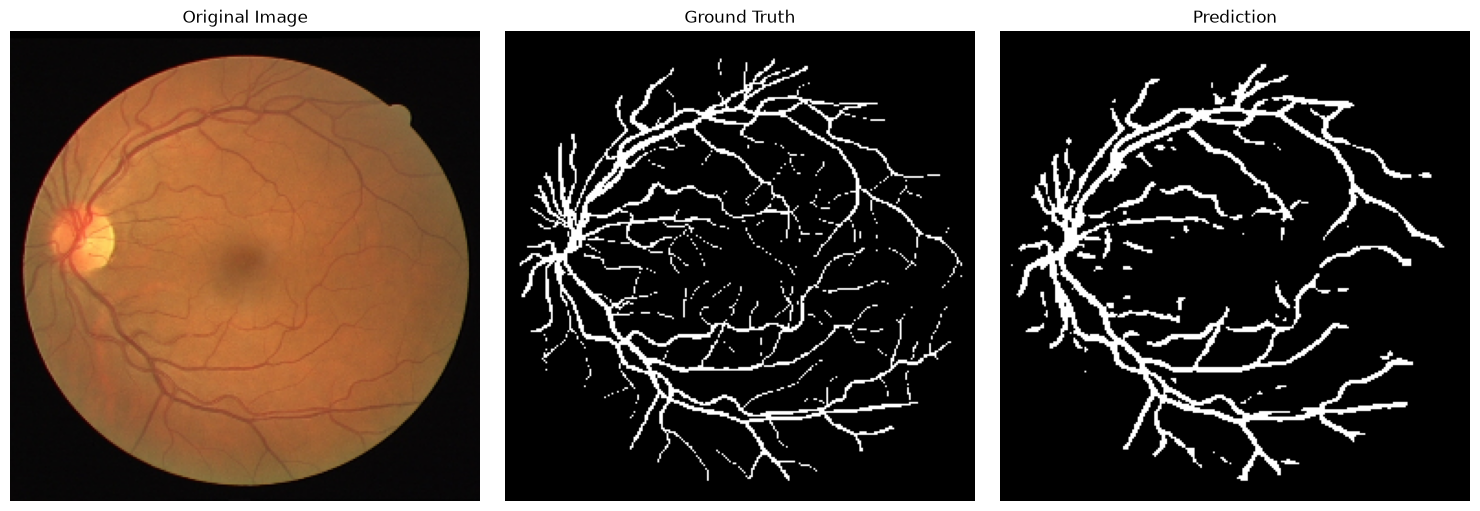

In [39]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [40]:
pretrained_model.eval()

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    dice_scores = []
    iou_scores = []

    with torch.no_grad():

        for i in range(len(test_dataset)):

            image, mask = test_dataset[i]

            image = image.unsqueeze(0).to(device)
            mask = mask.to(device)

            prediction = pretrained_model(image)

            prediction = torch.sigmoid(prediction)
            prediction = (prediction > threshold).float()

            intersection = (prediction * mask).sum()
            union = prediction.sum() + mask.sum() - intersection

            dice = (2 * intersection) / (
                prediction.sum() + mask.sum() + 1e-8
            )

            iou = intersection / (
                union + 1e-8
            )

            dice_scores.append(dice.item())
            iou_scores.append(iou.item())

    avg_dice = sum(dice_scores) / len(dice_scores)
    avg_iou = sum(iou_scores) / len(iou_scores)

    print(
        f"Threshold {threshold}: "
        f"Dice = {avg_dice:.4f}, "
        f"IoU = {avg_iou:.4f}"
    )

Threshold 0.3: Dice = 0.6694, IoU = 0.5038
Threshold 0.4: Dice = 0.6884, IoU = 0.5255
Threshold 0.5: Dice = 0.6976, IoU = 0.5361
Threshold 0.6: Dice = 0.6999, IoU = 0.5388
Threshold 0.7: Dice = 0.6935, IoU = 0.5315


In [41]:
BEST_THRESHOLD = 0.6

print("Best threshold:", BEST_THRESHOLD)
print("Best Test Dice:", pretrained_test_dice)
print("Best Test IoU:", pretrained_test_iou)

Best threshold: 0.6
Best Test Dice: 0.6975594371557235
Best Test IoU: 0.5361178010702133


In [42]:
tversky_loss = smp.losses.TverskyLoss(
    mode="binary",
    from_logits=True,
    alpha=0.3,
    beta=0.7
)

bce_loss = smp.losses.SoftBCEWithLogitsLoss()

def fine_vessel_loss(predictions, masks):
    return tversky_loss(predictions, masks) + bce_loss(predictions, masks)

print("Fine-vessel-aware loss created successfully!")

Fine-vessel-aware loss created successfully!


In [43]:
fine_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

fine_model = fine_model.to(device)

fine_optimizer = torch.optim.Adam(
    fine_model.parameters(),
    lr=1e-4
)

print("Fine-vessel model created successfully!")

Fine-vessel model created successfully!


In [44]:
fine_model.train()

for epoch in range(35):

    epoch_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        fine_optimizer.zero_grad()

        predictions = fine_model(images)

        loss = fine_vessel_loss(predictions, masks)

        loss.backward()
        fine_optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/35 - "
        f"Loss: {avg_loss:.4f}"
    )

Epoch 1/35 - Loss: 1.4272
Epoch 2/35 - Loss: 1.3251
Epoch 3/35 - Loss: 1.2499
Epoch 4/35 - Loss: 1.1906
Epoch 5/35 - Loss: 1.1359
Epoch 6/35 - Loss: 1.0939
Epoch 7/35 - Loss: 1.0479
Epoch 8/35 - Loss: 1.0084
Epoch 9/35 - Loss: 0.9716
Epoch 10/35 - Loss: 0.9381
Epoch 11/35 - Loss: 0.9083
Epoch 12/35 - Loss: 0.8793
Epoch 13/35 - Loss: 0.8577
Epoch 14/35 - Loss: 0.8342
Epoch 15/35 - Loss: 0.8106
Epoch 16/35 - Loss: 0.7888
Epoch 17/35 - Loss: 0.7694
Epoch 18/35 - Loss: 0.7545
Epoch 19/35 - Loss: 0.7388
Epoch 20/35 - Loss: 0.7161
Epoch 21/35 - Loss: 0.7014
Epoch 22/35 - Loss: 0.6831
Epoch 23/35 - Loss: 0.6679
Epoch 24/35 - Loss: 0.6511
Epoch 25/35 - Loss: 0.6362
Epoch 26/35 - Loss: 0.6244
Epoch 27/35 - Loss: 0.6114
Epoch 28/35 - Loss: 0.5989
Epoch 29/35 - Loss: 0.5900
Epoch 30/35 - Loss: 0.5788
Epoch 31/35 - Loss: 0.5656
Epoch 32/35 - Loss: 0.5567
Epoch 33/35 - Loss: 0.5466
Epoch 34/35 - Loss: 0.5389
Epoch 35/35 - Loss: 0.5283


In [45]:
fine_model.eval()

dice_scores = []
iou_scores = []

with torch.no_grad():

    for i in range(len(test_dataset)):

        image, mask = test_dataset[i]

        image = image.unsqueeze(0).to(device)
        mask = mask.to(device)

        prediction = fine_model(image)

        prediction = torch.sigmoid(prediction)
        prediction = (prediction > 0.5).float()

        intersection = (prediction * mask).sum()
        union = prediction.sum() + mask.sum() - intersection

        dice = (2 * intersection) / (
            prediction.sum() + mask.sum() + 1e-8
        )

        iou = intersection / (
            union + 1e-8
        )

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())

avg_dice = sum(dice_scores) / len(dice_scores)
avg_iou = sum(iou_scores) / len(iou_scores)

print(f"Fine-vessel model Test Dice: {avg_dice:.4f}")
print(f"Fine-vessel model Test IoU: {avg_iou:.4f}")

Fine-vessel model Test Dice: 0.7075
Fine-vessel model Test IoU: 0.5479


In [46]:
fine_model.eval()

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    dice_scores = []
    iou_scores = []

    with torch.no_grad():

        for i in range(len(test_dataset)):

            image, mask = test_dataset[i]

            image = image.unsqueeze(0).to(device)
            mask = mask.to(device)

            prediction = fine_model(image)

            prediction = torch.sigmoid(prediction)
            prediction = (prediction > threshold).float()

            intersection = (prediction * mask).sum()
            union = prediction.sum() + mask.sum() - intersection

            dice = (2 * intersection) / (
                prediction.sum() + mask.sum() + 1e-8
            )

            iou = intersection / (
                union + 1e-8
            )

            dice_scores.append(dice.item())
            iou_scores.append(iou.item())

    avg_dice = sum(dice_scores) / len(dice_scores)
    avg_iou = sum(iou_scores) / len(iou_scores)

    print(
        f"Threshold {threshold}: "
        f"Dice = {avg_dice:.4f}, "
        f"IoU = {avg_iou:.4f}"
    )

Threshold 0.3: Dice = 0.6727, IoU = 0.5075
Threshold 0.4: Dice = 0.6950, IoU = 0.5331
Threshold 0.5: Dice = 0.7075, IoU = 0.5479
Threshold 0.6: Dice = 0.7113, IoU = 0.5523
Threshold 0.7: Dice = 0.7076, IoU = 0.5479


In [47]:
import os

os.makedirs("../models", exist_ok=True)

torch.save(
    fine_model.state_dict(),
    "../models/unet_resnet34_tversky_bce35.pth"
)

print("Winning model saved successfully!")

Winning model saved successfully!


In [48]:
fine_model.eval()

image, mask = test_dataset[0]

with torch.no_grad():
    prediction = fine_model(
        image.unsqueeze(0).to(device)
    )

prediction = torch.sigmoid(prediction)
prediction = (prediction > 0.6).float()

prediction = prediction.squeeze().cpu().numpy()
image_np = image.permute(1, 2, 0).numpy()
mask_np = mask.squeeze().numpy()

print("Winning model prediction generated successfully!")

Winning model prediction generated successfully!


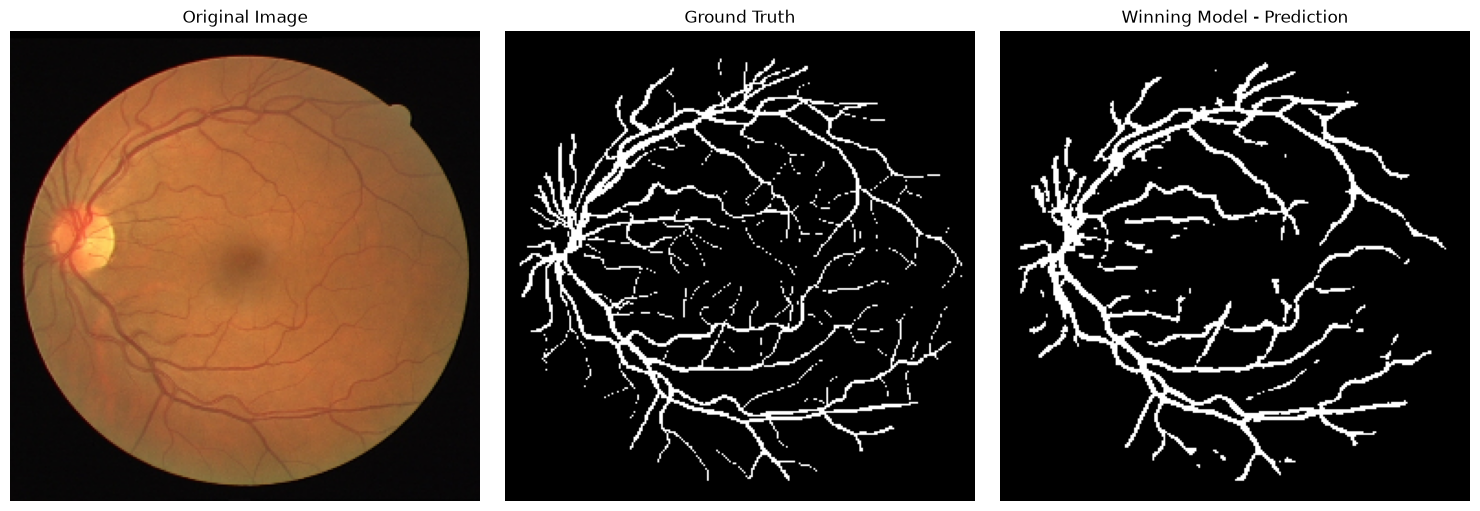

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("Winning Model - Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [50]:
# ==========================================
# FINAL MODEL RESULTS
# ==========================================

final_model_name = "U-Net with ResNet34 (ImageNet pretrained)"
final_loss = "Tversky Loss + BCE"
final_epochs = 35
final_threshold = 0.6
final_dice = 0.7113
final_iou = 0.5523

print("==========================================")
print("FINAL MODEL")
print("==========================================")
print("Architecture :", final_model_name)
print("Loss         :", final_loss)
print("Epochs       :", final_epochs)
print("Threshold    :", final_threshold)
print("Test Dice    :", final_dice)
print("Test IoU     :", final_iou)
print("==========================================")

FINAL MODEL
Architecture : U-Net with ResNet34 (ImageNet pretrained)
Loss         : Tversky Loss + BCE
Epochs       : 35
Threshold    : 0.6
Test Dice    : 0.7113
Test IoU     : 0.5523
